# Pre processamento

Esse notebook tem o objetivo de processar a imagem do cachorro para extrair os pontos de interesse que serão usados para guiar a tartaruga no ambiente do ROS. O processo envolve recortar a imagem para focar apenas no cachorro, aplicar um filtro de detecção de bordas e extrair os pontos relevantes.

In [41]:
import cv2  # somente para carregar a imagem
import numpy as np
import matplotlib.pyplot as plt
import json
import os

## 1. Carregar a imagem

&emsp;`cv2.imread` devolve BGR. Convertendo para RGB garantimos cores corretas na visualizacao.

shape original: (720, 1280, 3)


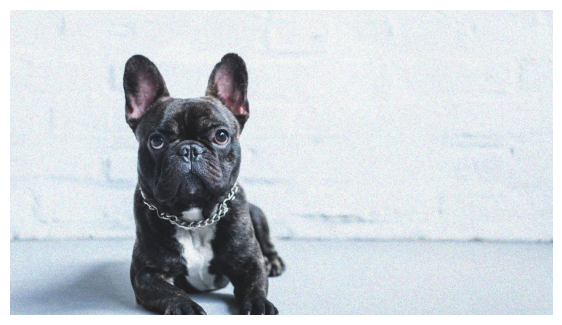

In [42]:
IMG_PATH = "../img/dog.jpg"
bgr = cv2.imread(IMG_PATH)
if bgr is None:
    raise FileNotFoundError(f"Imagem nao encontrada: {IMG_PATH}")

img_rgb = bgr[:, :, ::-1]
print("shape original:", bgr.shape)

plt.figure(figsize=(7, 4))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

## 2. Recorte (ROI) e reamostragem

&emsp;Recortar remove fundo e sombra, ajudando a silhueta. A reamostragem reduz custo de processamento.

shape roi: (648, 448, 3)
shape small: (162, 112, 3)


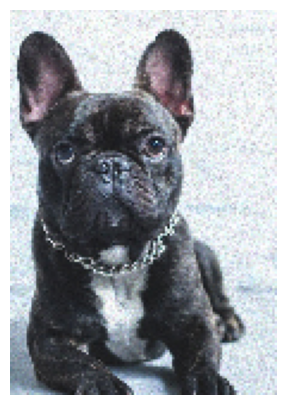

In [43]:
def crop_roi(img, top=0.0, bottom=0.0, left=0.0, right=0.0):
    H, W = img.shape[:2]
    y0, y1 = int(H * top), int(H * (1 - bottom))
    x0, x1 = int(W * left), int(W * (1 - right))
    return img[y0:y1, x0:x1]

def downsample(img, factor):
    return img[::factor, ::factor]

TOP = 0.1
BOTTOM = 0.0
LEFT = 0.2
RIGHT = 0.45

img_roi = crop_roi(img_rgb, top=TOP, bottom=BOTTOM, left=LEFT, right=RIGHT)
DOWNSAMPLE = 4
img_small = downsample(img_roi, DOWNSAMPLE)
print("shape roi:", img_roi.shape)
print("shape small:", img_small.shape)

plt.figure(figsize=(5, 5))
plt.imshow(img_small)
plt.axis("off")
plt.show()

## 3. Tons de cinza

&emsp;Bordas dependem de intensidade, entao reduzimos para 1 canal usando luminancia.

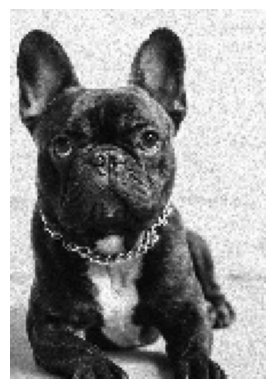

In [44]:
def rgb_to_gray(img):
    r = img[:, :, 0].astype(np.float32)
    g = img[:, :, 1].astype(np.float32)
    b = img[:, :, 2].astype(np.float32)
    gray = 0.299 * r + 0.587 * g + 0.114 * b
    return gray.astype(np.uint8)

gray = rgb_to_gray(img_small)
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.show()

## 4. Suavizacao Gaussiana

&emsp;Suavizar reduz ruido antes do Sobel, preservando melhor a silhueta.

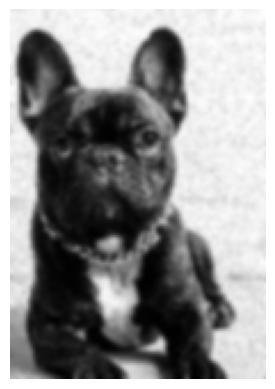

In [45]:
def gaussian_kernel(size=5, sigma=1.0):
    c = size // 2
    k = np.zeros((size, size), np.float32)
    for y in range(size):
        for x in range(size):
            k[y, x] = np.exp(-((x - c) ** 2 + (y - c) ** 2) / (2 * sigma ** 2))
    return k / k.sum()

def convolve2d(img, kernel):
    pad = kernel.shape[0] // 2
    padded = np.pad(img, pad, mode="edge").astype(np.float32)
    out = np.zeros(img.shape, np.float32)
    H, W = img.shape
    kh, kw = kernel.shape
    for y in range(H):
        for x in range(W):
            region = padded[y:y + kh, x:x + kw]
            out[y, x] = np.sum(region * kernel)
    return out

smooth = convolve2d(gray, gaussian_kernel(5, 1.0)).astype(np.uint8)
plt.imshow(smooth, cmap="gray")
plt.axis("off")
plt.show()

## 5. Deteccao de bordas (Sobel)

&emsp;O Sobel calcula gradientes em X e Y; a magnitude indica onde a borda e forte.

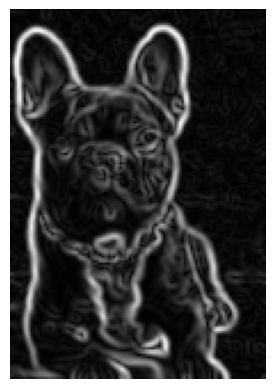

In [46]:
sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], np.float32)
sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], np.float32)

grad_x = convolve2d(smooth, sobel_x)
grad_y = convolve2d(smooth, sobel_y)
edge_mag = np.sqrt(grad_x ** 2 + grad_y ** 2)
if edge_mag.max() > 0:
    edge_mag = edge_mag / edge_mag.max() * 255.0
edge_mag = edge_mag.astype(np.uint8)

plt.imshow(edge_mag, cmap="gray")
plt.axis("off")
plt.show()

## 6. Segmentacao por limiar de Otsu

&emsp;Otsu escolhe um limiar automatico separando fundo claro e objeto escuro.

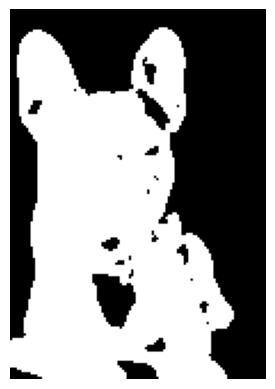

In [47]:
def otsu_threshold(img):
    hist = np.bincount(img.ravel(), minlength=256).astype(np.float64)
    total = img.size
    sum_total = np.dot(np.arange(256), hist)
    sum_b = 0.0
    weight_b = 0.0
    best_var = -1.0
    best_t = 0
    for t in range(256):
        weight_b += hist[t]
        if weight_b == 0:
            continue
        weight_f = total - weight_b
        if weight_f == 0:
            break
        sum_b += t * hist[t]
        mean_b = sum_b / weight_b
        mean_f = (sum_total - sum_b) / weight_f
        var_between = weight_b * weight_f * (mean_b - mean_f) ** 2
        if var_between > best_var:
            best_var = var_between
            best_t = t
    return best_t

t = otsu_threshold(smooth)
OTSU_RELAX = 0  # aumente para aceitar pixels mais claros
t_relax = min(t + OTSU_RELAX, 255)
mask = (smooth < t_relax).astype(np.uint8)

plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.show()

## 7. Operacoes morfologicas

&emsp;Abertura remove pontos soltos; fechamento preenche buracos na silhueta.

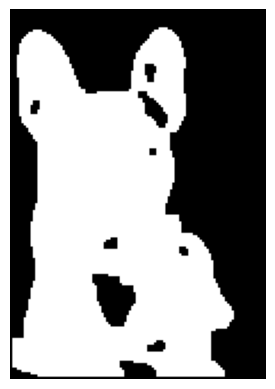

In [48]:
def dilate(m, size=3):
    p = size // 2
    pad = np.pad(m, p)
    out = np.zeros(m.shape, np.uint8)
    H, W = m.shape
    for y in range(H):
        for x in range(W):
            if pad[y:y + size, x:x + size].max() > 0:
                out[y, x] = 1
    return out

def erode(m, size=3):
    p = size // 2
    pad = np.pad(m, p)
    out = np.zeros(m.shape, np.uint8)
    H, W = m.shape
    for y in range(H):
        for x in range(W):
            if pad[y:y + size, x:x + size].min() > 0:
                out[y, x] = 1
    return out

def open_mask(m, size=3):
    return dilate(erode(m, size), size)

def close_mask(m, size=3):
    return erode(dilate(m, size), size)

K_MORPH = 3
mask_morph = close_mask(mask, K_MORPH)
mask_morph = open_mask(mask_morph, K_MORPH)

plt.imshow(mask_morph, cmap="gray")
plt.axis("off")
plt.show()

## 8. Maior componente conexo

&emsp;Mantemos apenas o maior grupo conectado para ficar com o cachorro.

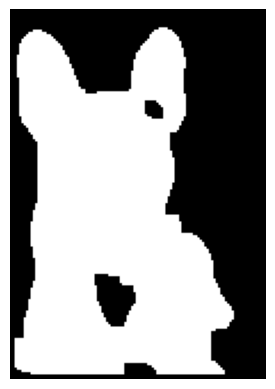

In [49]:
def largest_component(m):
    H, W = m.shape
    visit = np.zeros(m.shape, np.uint8)
    best = []
    for sy in range(H):
        for sx in range(W):
            if m[sy, sx] and not visit[sy, sx]:
                stack = [(sy, sx)]
                visit[sy, sx] = 1
                comp = []
                while stack:
                    y, x = stack.pop()
                    comp.append((y, x))
                    for dy in (-1, 0, 1):
                        for dx in (-1, 0, 1):
                            ny, nx = y + dy, x + dx
                            if 0 <= ny < H and 0 <= nx < W and m[ny, nx] and not visit[ny, nx]:
                                visit[ny, nx] = 1
                                stack.append((ny, nx))
                if len(comp) > len(best):
                    best = comp
    out = np.zeros(m.shape, np.uint8)
    for y, x in best:
        out[y, x] = 1
    return out

silhouette = largest_component(mask_morph)
silhouette = close_mask(silhouette, 5)

plt.imshow(silhouette, cmap="gray")
plt.axis("off")
plt.show()

## 9. Rastreamento de contorno (Moore)

&emsp;Seguimos a borda em ordem para criar uma sequencia de pontos fechada.

contour points: 502


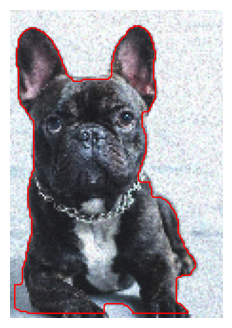

In [50]:
def trace_contour(m):
    H, W = m.shape
    dirs = [(0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1), (-1, 0), (-1, 1)]
    start = None
    for y in range(H):
        for x in range(W):
            if m[y, x]:
                start = (y, x)
                break
        if start:
            break
    if start is None:
        return []
    contour = [start]
    cur = start
    back_dir = 4
    for _ in range(4 * H * W):
        found = False
        for k in range(8):
            nd = (back_dir + 1 + k) % 8
            ny, nx = cur[0] + dirs[nd][0], cur[1] + dirs[nd][1]
            if 0 <= ny < H and 0 <= nx < W and m[ny, nx]:
                cur = (ny, nx)
                back_dir = (nd + 4) % 8
                contour.append(cur)
                found = True
                break
        if not found:
            break
        if cur == start:
            break
    return contour

contour = trace_contour(silhouette)
print("contour points:", len(contour))
ys = [p[0] for p in contour]
xs = [p[1] for p in contour]

plt.figure(figsize=(7, 4))
plt.imshow(img_small)
plt.plot(xs, ys, "-r", lw=1)
plt.axis("off")
plt.show()

## 10. Simplificacao do contorno

&emsp;Reduzimos o numero de pontos por subamostragem para acelerar o desenho no turtlesim.

In [51]:
def subsample_contour(contour, step=3):
    pts = contour[::step]
    if pts and pts[0] != pts[-1]:
        pts.append(pts[0])
    return pts

STEP = 3
contour_simple = subsample_contour(contour, STEP)
print("points after simplify:", len(contour_simple))

points after simplify: 168


## 11. Mapeamento para o espaco do turtlesim

&emsp;Escalamos para 0..11, preservamos proporcao e invertemos o eixo Y.

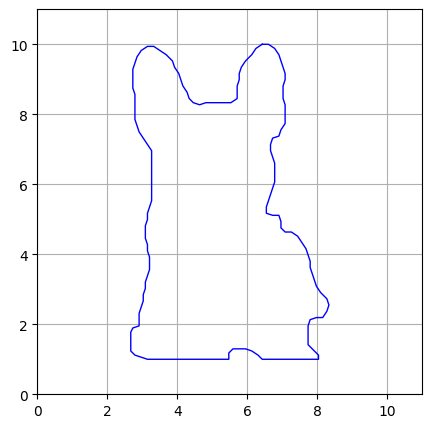

In [52]:
def map_to_turtlesim(contour, margin=1.0, size=11.0):
    ys = np.array([p[0] for p in contour], float)
    xs = np.array([p[1] for p in contour], float)
    minx, maxx = xs.min(), xs.max()
    miny, maxy = ys.min(), ys.max()
    width, height = maxx - minx, maxy - miny
    span = size - 2 * margin
    scale = min(span / width, span / height)
    cx, cy = (minx + maxx) / 2, (miny + maxy) / 2
    center = size / 2
    pts = []
    for y, x in contour:
        tx = center + (x - cx) * scale
        ty = center - (y - cy) * scale
        pts.append((round(float(tx), 3), round(float(ty), 3)))
    return pts

points_turtle = map_to_turtlesim(contour_simple)
px = [p[0] for p in points_turtle]
py = [p[1] for p in points_turtle]

plt.figure(figsize=(5, 5))
plt.plot(px, py, "-b", lw=1)
plt.xlim(0, 11)
plt.ylim(0, 11)
plt.gca().set_aspect("equal")
plt.grid(True)
plt.show()

## 12. Exportar pontos

&emsp;Salvamos os pontos em JSON para o no do ROS 2 consumir e desenhar.

In [53]:
output_dir = "../src/turtle/resource"
os.makedirs(output_dir, exist_ok=True)
out_path = os.path.join(output_dir, "points.json")
with open(out_path, "w") as f:
    json.dump({"points": points_turtle}, f)